In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
from google.colab import files

uploaded = files.upload()

Saving sarcastic_headlines.csv to sarcastic_headlines.csv


In [3]:
df = pd.read_csv("sarcastic_headlines.csv")

In [4]:
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


## Basic Data Understanding

In [5]:
#dataset info
df.info()

#Missing values
df.isnull().sum()

#Class distribution
df['is_sarcastic'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB


,count
is_sarcastic,
0,14985
1,13634


## Visualize Class Distribution

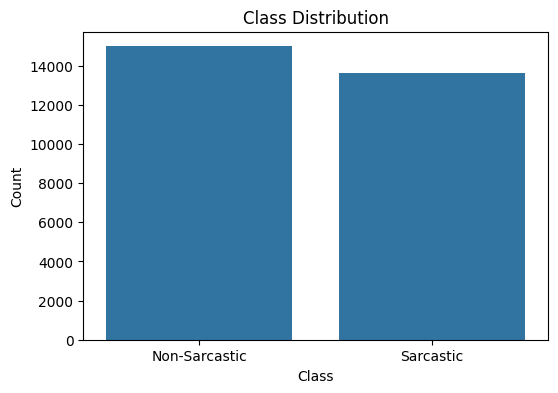

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_sarcastic',
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks(
    [0,1],
    ['Non-Sarcastic', 'Sarcastic']
)

plt.show()

In [7]:
!pip install nltk

In [8]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.8 MB/s eta 0:00:00


In [20]:
# Import required libraries

import re
import string
import contractions
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [21]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [12]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [22]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Load stopwords
stop_words = set(stopwords.words('english'))

## Text cleaning function

In [23]:
# Text Cleaning Function

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol only
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into sentence
    text = ' '.join(cleaned_words)

    return text

In [24]:
# Download Punkt Tab Resource

nltk.download('punkt_tab')

print("Punkt tab downloaded successfully.")

Punkt tab downloaded successfully.


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [25]:
import string
from nltk.tokenize import word_tokenize
# Apply text preprocessing to headline column
df['clean_headline'] = df['headline'].apply(clean_text)

In [26]:
#Compare Original and Cleaned Text
df[['headline', 'clean_headline', 'is_sarcastic']].head(10)

,headline,clean_headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1
5,my white inheritance,white inheritance,0
6,5 ways to file your taxes with less stress,way file tax less stress,0
7,richard branson's global-warming donation near...,richard bransons globalwarming donation nearly...,1
8,shadow government getting too large to meet in...,shadow government getting large meet marriott ...,1
9,lots of parents know this scenario,lot parent know scenario,0


In [27]:
#Check Empty Cleaned Rows
empty_rows = (df['clean_headline'].str.strip() == '').sum()

print("Empty Rows:", empty_rows)

Empty Rows: 2


In [28]:
df = df[df['clean_headline'].str.strip() != '']

print("Updated shape:", df.shape)

Updated shape: (28617, 3)


## Headline length distribution

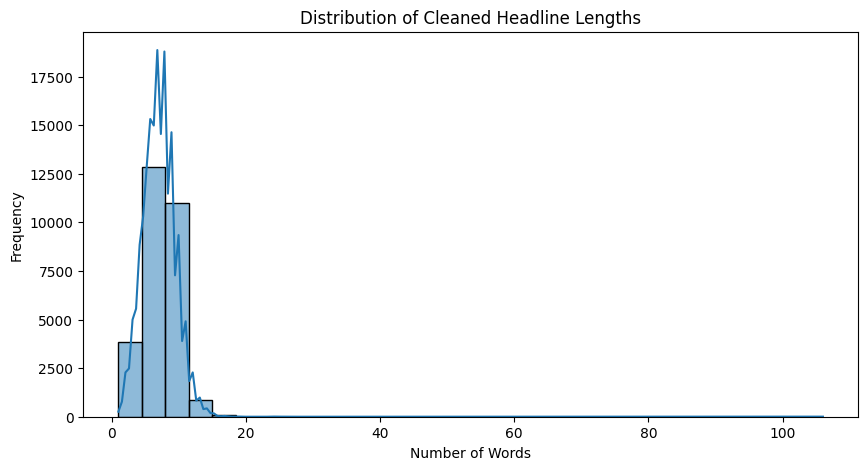

In [29]:
headline_lengths = df['clean_headline'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(headline_lengths, bins=30, kde=True)

plt.title("Distribution of Cleaned Headline Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [30]:
from collections import Counter

all_words = " ".join(df['clean_headline'])
word_list = all_words.split()

word_freq = Counter(word_list)

common_words = word_freq.most_common(20)

freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

freq_df

,Word,Frequency
0,trump,1794
1,new,1677
2,man,1507
3,woman,884
4,say,709
5,report,690
6,get,637
7,day,589
8,one,579
9,year,558


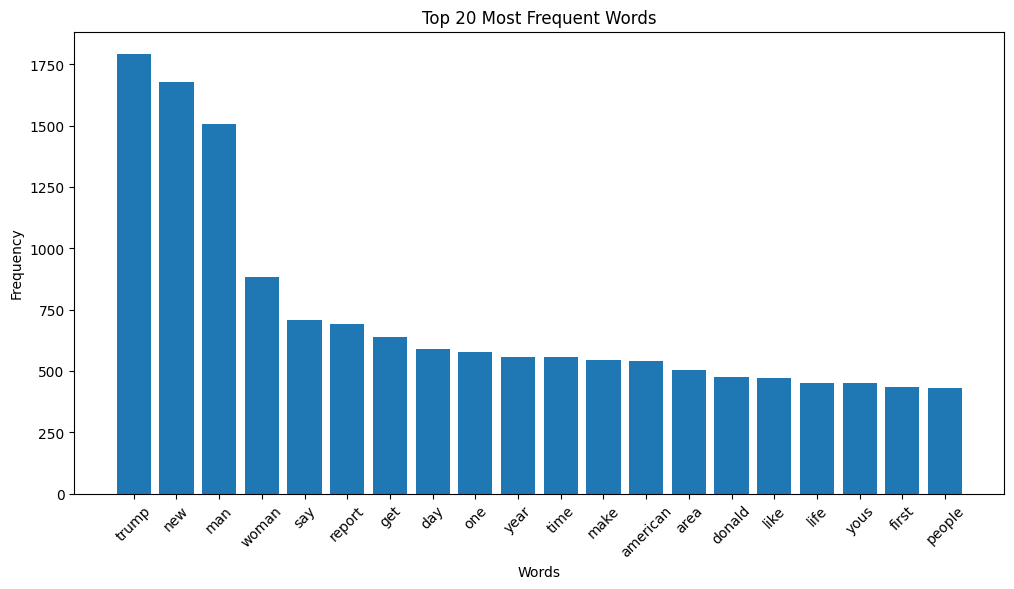

In [31]:
plt.figure(figsize=(12,6))

plt.bar(freq_df['Word'], freq_df['Frequency'])

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [32]:
!pip install wordcloud

In [33]:
# Import WordCloud for text visualization
from wordcloud import WordCloud

In [34]:
# Generate word cloud using all cleaned words
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

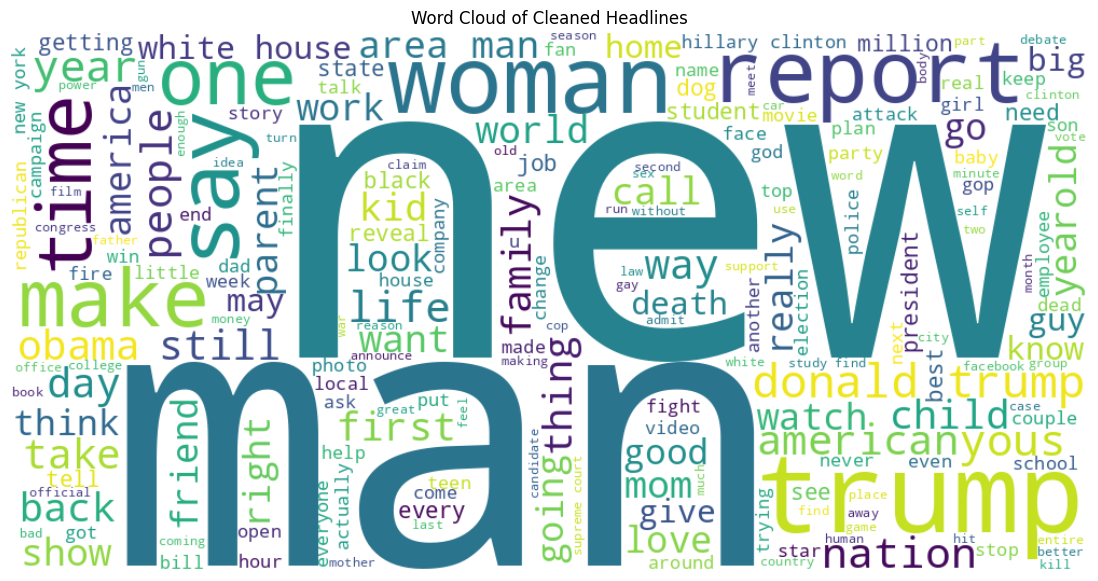

In [35]:
# Display the word cloud
plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Word Cloud of Cleaned Headlines")

plt.show()

In [36]:
# Separate sarcastic headlines into one text block
sarcastic_text = " ".join(
    df[df['is_sarcastic'] == 1]['clean_headline']
)

# Separate non-sarcastic headlines into one text block
non_sarcastic_text = " ".join(
    df[df['is_sarcastic'] == 0]['clean_headline']
)

In [37]:
# Count most frequent words in sarcastic headlines
sarcastic_words = sarcastic_text.split()

sarcastic_freq = Counter(sarcastic_words)

top_sarcastic = sarcastic_freq.most_common(15)

sarcastic_df = pd.DataFrame(
    top_sarcastic,
    columns=['Word', 'Frequency']
)

sarcastic_df

,Word,Frequency
0,man,1274
1,new,1000
2,report,576
3,area,490
4,woman,472
5,nation,389
6,trump,381
7,get,339
8,time,332
9,day,325


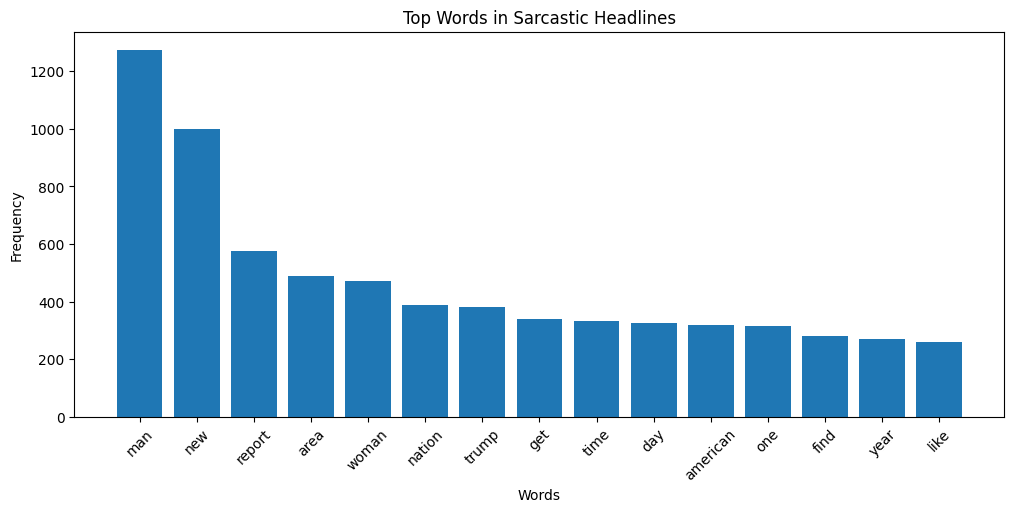

In [38]:
# Plot top words in sarcastic headlines
plt.figure(figsize=(12,5))

plt.bar(
    sarcastic_df['Word'],
    sarcastic_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top Words in Sarcastic Headlines")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [39]:
# Count most frequent words in non-sarcastic headlines
non_sarcastic_words = non_sarcastic_text.split()

non_sarcastic_freq = Counter(non_sarcastic_words)

top_non_sarcastic = non_sarcastic_freq.most_common(15)

non_sarcastic_df = pd.DataFrame(
    top_non_sarcastic,
    columns=['Word', 'Frequency']
)

non_sarcastic_df

,Word,Frequency
0,trump,1413
1,new,677
2,say,499
3,donald,455
4,woman,412
5,make,308
6,get,298
7,year,288
8,one,264
9,day,264


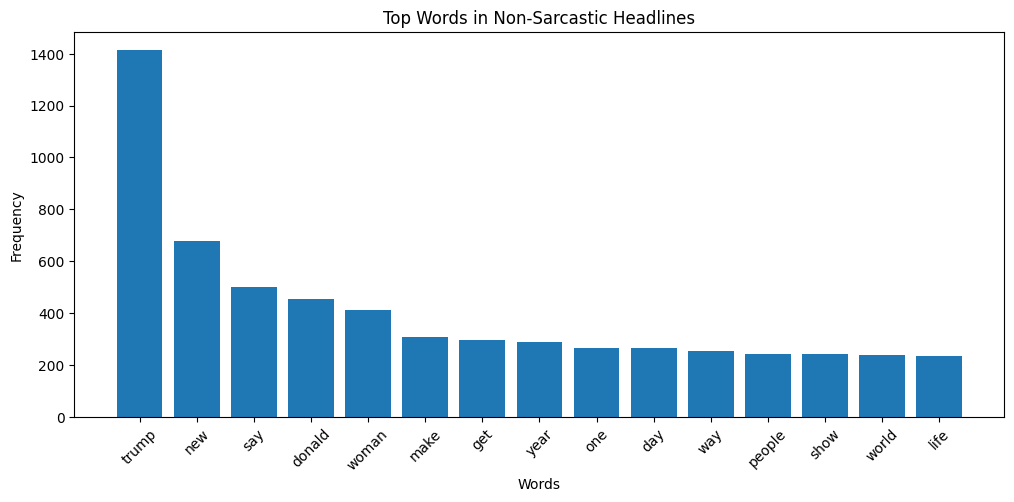

In [40]:
# Plot top words in non-sarcastic headlines
plt.figure(figsize=(12,5))

plt.bar(
    non_sarcastic_df['Word'],
    non_sarcastic_df['Frequency']
)

plt.xticks(rotation=45)

plt.title("Top Words in Non-Sarcastic Headlines")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

## Define Features and Labels

In [41]:
# Define input features
X = df['clean_headline']

# Define target labels
y = df['is_sarcastic']

In [42]:
# Import train_test_split
from sklearn.model_selection import train_test_split


# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
# Display number of training and testing samples
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 22893
Testing Samples: 5724


In [44]:
# Import tokenizer and padding tools
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

##Initialize Tokenizer

In [45]:
# Define vocabulary size
vocab_size = 10000

# Define out-of-vocabulary token
oov_token = "<OOV>"


# Initialize tokenizer
tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token=oov_token
)




In [46]:
# Fit tokenizer on training text
tokenizer.fit_on_texts(X_train)

## convert Text into sequences

In [47]:
# Convert training text into sequences
train_sequences = tokenizer.texts_to_sequences(X_train)

# Convert testing text into sequences
test_sequences = tokenizer.texts_to_sequences(X_test)

In [48]:
# Display original headline
print(X_train.iloc[0])

white house block seahawks punt


In [49]:
# Display numerical sequence
print(train_sequences[0])

[32, 25, 835, 8372, 1]


## Analyze Sequence lengths

In [50]:
# Calculate sequence lengths
sequence_lengths = [
    len(sequence)
    for sequence in train_sequences
]

In [51]:
# Calculate 95th percentile sequence length
max_length = int(
    np.percentile(sequence_lengths, 95)
)

print("Padding Length:", max_length)

Padding Length: 11


## Apply Padding

In [52]:
# Apply padding to training sequences
X_train_padded = pad_sequences(
    train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Apply padding to testing sequences
X_test_padded = pad_sequences(
    test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Padding completed successfully.")


Padding completed successfully.


## Check Final Shapes

In [54]:
# Create Validation Dataset

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Final Training Shape:", X_train_final.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test_padded.shape)

Final Training Shape: (20603, 11)
Validation Shape: (2290, 11)
Testing Shape: (5724, 11)


## Model 1 — Simple RNN with Trainable Embedding Layer

In [55]:
# Import deep learning libraries
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.regularizers import l2

In [61]:
# Build Simple RNN model
model_rnn = Sequential()

# Input layer
model_rnn.add(
    Input(shape=(max_length,))
)

# Trainable embedding layer
model_rnn.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=32
    )
)

# Simple RNN layer
model_rnn.add(
    SimpleRNN(
        32,
        dropout=0.3,
        recurrent_dropout=0.2,

    )
)

# Dense hidden layer
model_rnn.add(
    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

# Dropout layer
model_rnn.add(
    Dropout(0.5)
)

# Output layer
model_rnn.add(
    Dense(
        1,
        activation='sigmoid'
    )
)
print("Simple RNN model created successfully.")

Simple RNN model created successfully.


In [62]:
# Display model architecture
model_rnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,625 (1.23 MB)

 Trainable params: 322,625 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Compile Simple RNN model
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [64]:
# Define early stopping callback

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [67]:
# Train Simple RNN model

history_rnn = model_rnn.fit(
    X_train_padded,
    y_train,

    validation_split=0.2,

    epochs=10,

    batch_size=64,

    callbacks=[early_stop]
)

Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6309 - loss: 0.6590 - val_accuracy: 0.7646 - val_loss: 0.5326
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7947 - loss: 0.5042 - val_accuracy: 0.7834 - val_loss: 0.4745
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8544 - loss: 0.4027 - val_accuracy: 0.7757 - val_loss: 0.5183
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8807 - loss: 0.3373 - val_accuracy: 0.7888 - val_loss: 0.4787


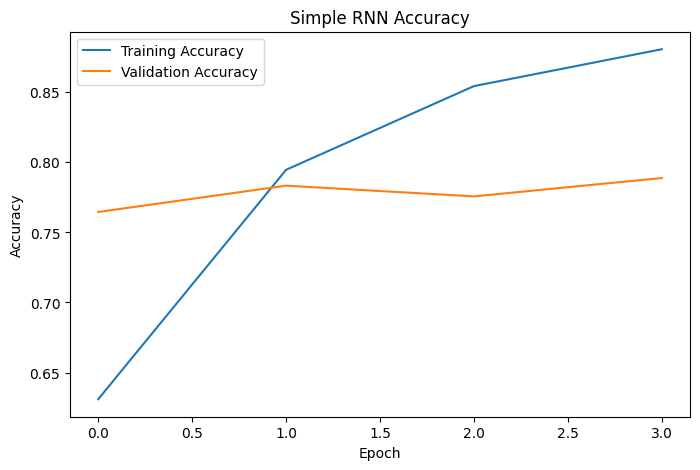

In [68]:
# Plot Simple RNN accuracy

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("Simple RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

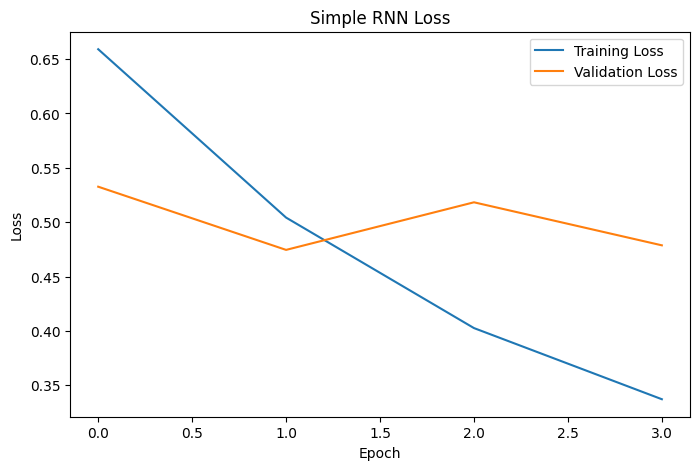

In [69]:
# Plot Simple RNN loss

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("Simple RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [70]:
# Import evaluation metrics

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [71]:
# Predict probabilities on test data

y_pred_prob_rnn = model_rnn.predict(X_test_padded)

179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [72]:
# Convert probabilities into binary class labels

y_pred_rnn = (y_pred_prob_rnn >= 0.5).astype(int)

In [73]:
# Calculate test accuracy

rnn_accuracy = accuracy_score(y_test, y_pred_rnn)

print("Simple RNN Test Accuracy:", rnn_accuracy)

Simple RNN Test Accuracy: 0.776554856743536


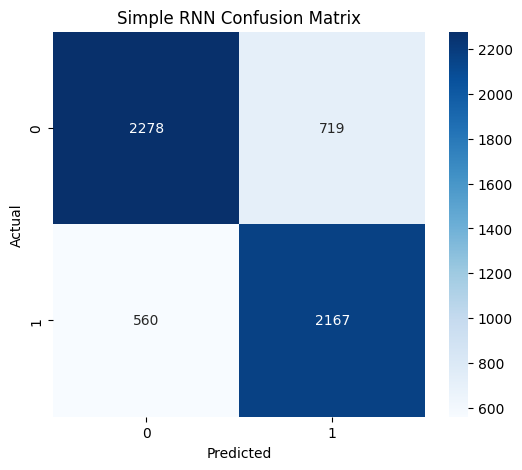

In [74]:
# Create confusion matrix

cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [75]:
# Print classification report

print(classification_report(y_test, y_pred_rnn))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      2997
           1       0.75      0.79      0.77      2727

    accuracy                           0.78      5724
   macro avg       0.78      0.78      0.78      5724
weighted avg       0.78      0.78      0.78      5724



The Simple RNN model achieved an overall test accuracy of approximately 78% on the sarcasm detection dataset. The model demonstrated balanced performance across both sarcastic and non-sarcastic classes, with precision and recall values remaining relatively close. The recall for the sarcastic class was slightly higher than its precision, indicating that the model was able to identify many sarcastic headlines correctly, although some non-sarcastic headlines were also misclassified as sarcastic.

During training, the model showed signs of mild overfitting, as training accuracy increased more rapidly than validation accuracy. However, the use of dropout and early stopping helped reduce excessive memorization and improved generalization performance. Overall, the Simple RNN model was able to capture basic sequential patterns in text, but its contextual understanding remained limited for complex sarcasm detection tasks.

In [76]:
# Import LSTM layer

from tensorflow.keras.layers import LSTM

In [77]:
# Build LSTM model

model_lstm = Sequential()

# Input layer
model_lstm.add(
    Input(shape=(max_length,))
)

# Trainable embedding layer
model_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=32
    )
)

# LSTM layer
model_lstm.add(
    LSTM(
        32,
        dropout=0.3,
        recurrent_dropout=0.2
    )
)

# Dense hidden layer
model_lstm.add(
    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

# Dropout layer
model_lstm.add(
    Dropout(0.5)
)

# Output layer
model_lstm.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

In [78]:
# Display LSTM model summary

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 11, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,865 (1.25 MB)

 Trainable params: 328,865 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Compile LSTM model

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [81]:
# Train LSTM model

history_lstm = model_lstm.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8875 - loss: 0.3116 - val_accuracy: 0.7884 - val_loss: 0.5081
Epoch 2/25
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9023 - loss: 0.2679 - val_accuracy: 0.7805 - val_loss: 0.5203


In [82]:
# Display best validation results for LSTM

best_lstm_epoch = np.argmax(
    history_lstm.history['val_accuracy']
) + 1

best_lstm_val_accuracy = max(
    history_lstm.history['val_accuracy']
)

best_lstm_val_loss = min(
    history_lstm.history['val_loss']
)

print("Best LSTM Epoch:", best_lstm_epoch)
print("Best LSTM Validation Accuracy:", round(best_lstm_val_accuracy, 4))
print("Best LSTM Validation Loss:", round(best_lstm_val_loss, 4))

Best LSTM Epoch: 1
Best LSTM Validation Accuracy: 0.7884
Best LSTM Validation Loss: 0.5081


In [83]:
# Predict using LSTM model

lstm_predictions = model_lstm.predict(X_test_padded)

lstm_predictions = (lstm_predictions > 0.5).astype(int)

print("Prediction completed successfully.")

179/179 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step
Prediction completed successfully.


In [84]:
# Classification report for LSTM

print("LSTM Classification Report:")
print(classification_report(y_test, lstm_predictions))

LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      2997
           1       0.77      0.79      0.78      2727

    accuracy                           0.79      5724
   macro avg       0.79      0.79      0.79      5724
weighted avg       0.79      0.79      0.79      5724



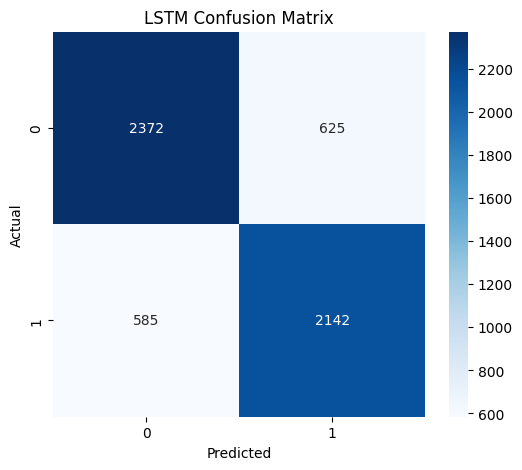

In [85]:
# Confusion matrix for LSTM

lstm_cm = confusion_matrix(y_test, lstm_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [86]:
# Calculate LSTM accuracy

lstm_accuracy = accuracy_score(y_test, lstm_predictions)

print("LSTM Test Accuracy:", lstm_accuracy)

LSTM Test Accuracy: 0.7886093640810622


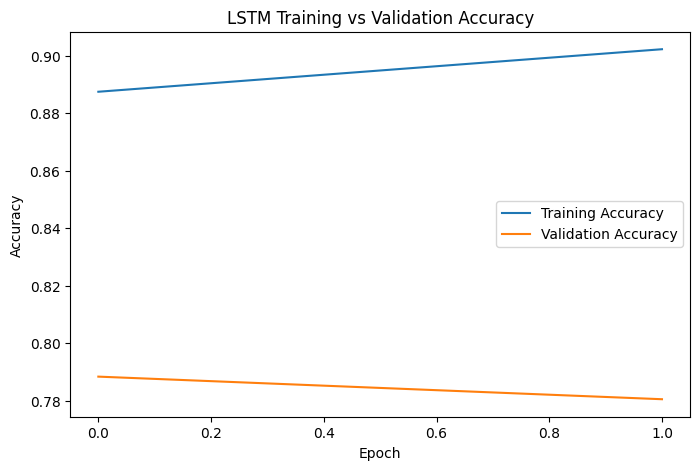

In [87]:
# Plot LSTM training vs validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

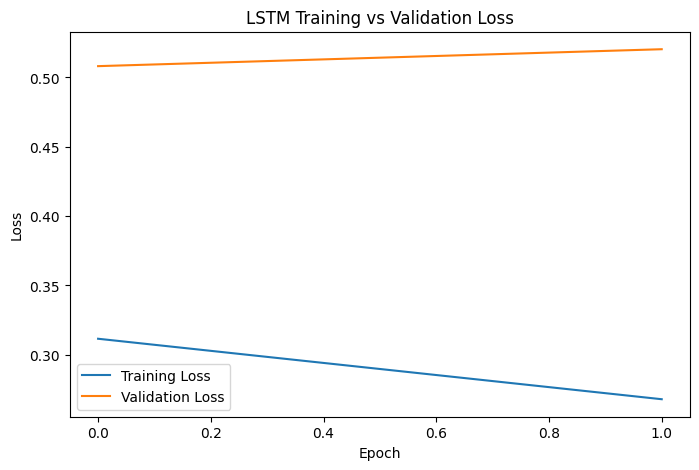

In [88]:
# Plot LSTM training vs validation loss

plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

The LSTM model achieved a test accuracy of approximately 78.86% on the sarcasm detection dataset. Compared to the Simple RNN model, the LSTM showed slightly improved performance due to its ability to capture longer contextual dependencies within text sequences. The confusion matrix indicates that the model correctly classified a large number of both sarcastic and non-sarcastic headlines, although some misclassifications were still present.

The model achieved balanced performance across both classes, demonstrating relatively stable precision and recall values. However, the training process also showed signs of overfitting, as training accuracy increased faster than validation accuracy during later epochs. The use of dropout and early stopping helped reduce excessive overfitting and improved model generalization. Overall, the LSTM model performed better than the Simple RNN model in understanding sequential text patterns for sarcasm detection.

In [89]:
# Install gensim library
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.5 MB/s eta 0:00:00


In [90]:
# Import gensim downloader
import gensim.downloader as api

In [91]:
# Load pretrained GloVe embeddings
embedding_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [92]:
# Check sample word vector
embedding_model['trump']

array([ 0.45769  ,  0.85191  ,  0.31098  ,  1.3478   , -0.021703 ,
       -0.05467  , -0.17405  , -0.71014  , -0.57441  ,  0.49786  ,
       -0.89382  ,  0.58661  , -0.77013  ,  0.23779  ,  0.37652  ,
        1.3668   ,  0.34667  ,  0.082452 ,  0.17561  ,  0.056062 ,
        0.50818  ,  0.33751  , -0.8517   ,  0.034619 , -0.57237  ,
       -1.1534   , -0.54159  ,  0.24328  ,  0.018737 , -0.58645  ,
        0.15261  ,  0.53372  , -0.27601  ,  0.065097 ,  0.3968   ,
       -0.62892  ,  0.0046726,  0.081347 , -0.32579  , -0.60933  ,
       -0.36464  ,  0.17591  ,  0.0050718,  1.3606   , -0.78583  ,
        0.083121 , -0.75184  , -0.74226  ,  0.77053  ,  0.26394  ],
      dtype=float32)

In [93]:
# Get tokenizer word index
word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))

Vocabulary Size: 22574


In [94]:
# Define embedding dimension based on GloVe model
embedding_dim = 50

In [95]:
# Create empty embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))

In [96]:
# Fill embedding matrix with pretrained GloVe vectors
for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]

In [97]:
# Check embedding matrix shape
print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (10000, 50)


## Build Glove LSMT Model

In [98]:
# Build LSTM model with pretrained GloVe embeddings

model_glove_lstm = Sequential()

# Input layer
model_glove_lstm.add(
    Input(shape=(max_length,))
)

# Pretrained GloVe embedding layer
model_glove_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    )
)

# LSTM layer
model_glove_lstm.add(
    LSTM(
        32,
        dropout=0.3,
        recurrent_dropout=0.2
    )
)

# Dense hidden layer
model_glove_lstm.add(
    Dense(
        16,
        activation='relu',
        kernel_regularizer=l2(0.001)
    )
)

# Dropout layer
model_glove_lstm.add(
    Dropout(0.5)
)

# Output layer
model_glove_lstm.add(
    Dense(1, activation='sigmoid')
)

In [99]:
# Compile GloVe LSTM model

model_glove_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [100]:
# Display GloVe LSTM model summary

model_glove_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,169 (1.95 MB)

 Trainable params: 511,169 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
# Define early stopping callback

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [102]:
# Train GloVe LSTM model

history_glove_lstm = model_glove_lstm.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6255 - loss: 0.6590 - val_accuracy: 0.7235 - val_loss: 0.5705
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7359 - loss: 0.5596 - val_accuracy: 0.7718 - val_loss: 0.4881
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7815 - loss: 0.4881 - val_accuracy: 0.7890 - val_loss: 0.4564
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8138 - loss: 0.4446 - val_accuracy: 0.8008 - val_loss: 0.4387
Epoch 5/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8383 - loss: 0.3960 - val_accuracy: 0.8065 - val_loss: 0.4232
Epoch 6/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8580 - loss: 0.3613 - val_accuracy: 0.8085 - val_loss: 0.4358
Epoch 7/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8743 - loss: 0.3261 - val_accuracy: 0.8107 - val_loss: 0.4446


In [103]:
# Evaluate GloVe LSTM Model on Test Data

glove_lstm_loss, glove_lstm_accuracy = model_glove_lstm.evaluate(
    X_test_padded,
    y_test
)

print("GloVe LSTM Test Loss:", glove_lstm_loss)
print("GloVe LSTM Test Accuracy:", glove_lstm_accuracy)

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8073 - loss: 0.4215
GloVe LSTM Test Loss: 0.42151114344596863
GloVe LSTM Test Accuracy: 0.8073025941848755


In [104]:
# Predict Using GloVe LSTM Model

glove_lstm_predictions = model_glove_lstm.predict(X_test_padded)

glove_lstm_predictions = (
    glove_lstm_predictions > 0.5
).astype("int32")

print("Prediction completed successfully.")

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
Prediction completed successfully.


In [105]:
# Classification Report for GloVe LSTM

print("GloVe LSTM Classification Report:")

print(
    classification_report(
        y_test,
        glove_lstm_predictions
    )
)

GloVe LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82      2997
           1       0.82      0.76      0.79      2727

    accuracy                           0.81      5724
   macro avg       0.81      0.81      0.81      5724
weighted avg       0.81      0.81      0.81      5724



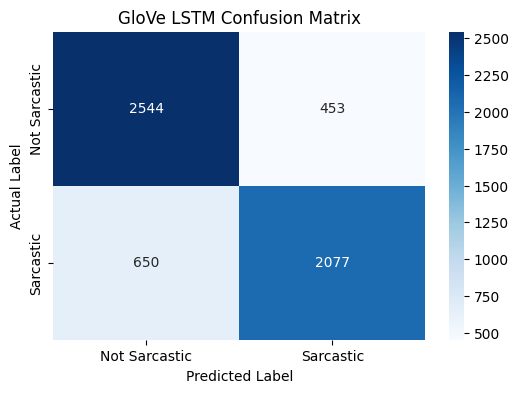

In [106]:
# Confusion Matrix for GloVe LSTM

glove_lstm_cm = confusion_matrix(
    y_test,
    glove_lstm_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    glove_lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Sarcastic', 'Sarcastic'],
    yticklabels=['Not Sarcastic', 'Sarcastic']
)

plt.title("GloVe LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

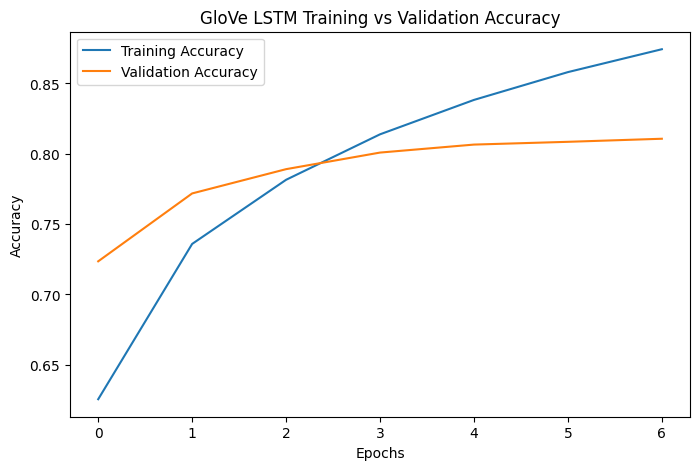

In [107]:
# Plot GloVe LSTM Training History

plt.figure(figsize=(8, 5))

plt.plot(
    history_glove_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_glove_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("GloVe LSTM Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

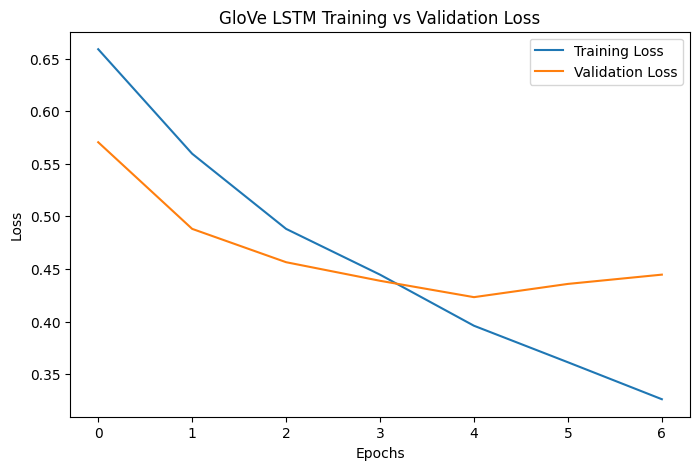

In [108]:
# Plot GloVe LSTM Training vs Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history_glove_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_glove_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("GloVe LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

##Model COmparision

In [109]:
# Create Model Comparison Table

model_comparison = pd.DataFrame({

    'Model': [
        'Simple RNN',
        'LSTM',
        'GloVe LSTM'
    ],

    'Test Accuracy': [
        rnn_accuracy,
        lstm_accuracy,
        glove_lstm_accuracy
    ]
})

# Display comparison table
model_comparison

,Model,Test Accuracy
0,Simple RNN,0.776555
1,LSTM,0.788609
2,GloVe LSTM,0.807303


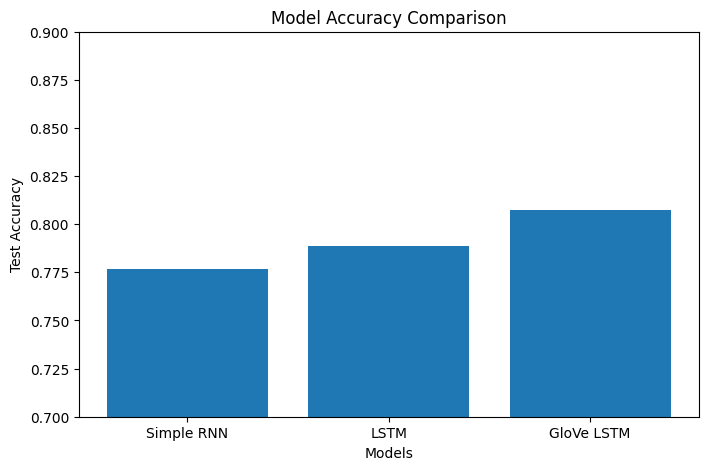

In [110]:
# Plot Model Accuracy Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['Test Accuracy']
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")

plt.ylim(0.7, 0.9)

plt.show()

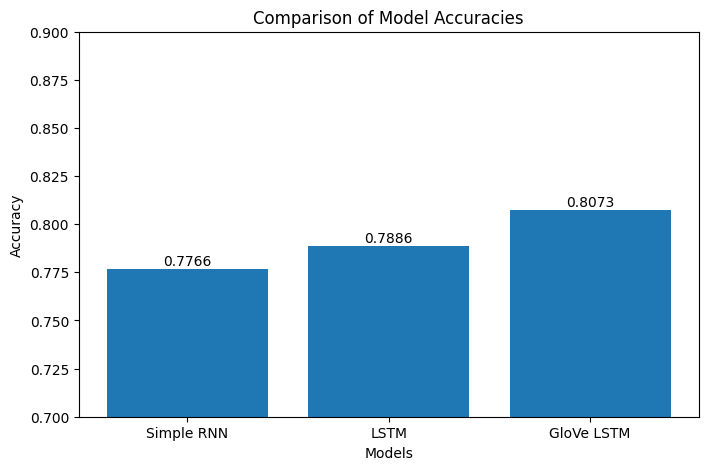

In [111]:
# Plot Model Accuracy Comparison with Accuracy Labels

plt.figure(figsize=(8, 5))

bars = plt.bar(
    model_comparison['Model'],
    model_comparison['Test Accuracy']
)

# Add accuracy values above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f'{height:.4f}',
        ha='center'
    )

plt.title("Comparison of Model Accuracies")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.7, 0.9)

plt.show()

In [112]:
# Display Best Performing Model

best_model = model_comparison.loc[
    model_comparison['Test Accuracy'].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model            GloVe LSTM
Test Accuracy      0.807303
Name: 2, dtype: object


## Error Analysis

In [113]:
# Create dataframe for error analysis

error_df = pd.DataFrame({

    'headline': X_test.values,

    'actual_label': y_test.values,

    'predicted_label': glove_lstm_predictions.flatten()
})

# Display first rows
error_df.head()

,headline,actual_label,predicted_label
0,way boost empathy,0,0
1,kris kobach defends using private email govern...,0,0
2,group christie campaign deserter found forest,1,0
3,sometimesgross nonsexual intimacy female frien...,0,0
4,democratic congressman protest trump environme...,1,0


In [114]:
# Filter incorrect predictions

incorrect_predictions = error_df[
    error_df['actual_label']
    !=
    error_df['predicted_label']
]

print(
    "Total Incorrect Predictions:",
    len(incorrect_predictions)
)

Total Incorrect Predictions: 1103


In [115]:
# Display random misclassified examples

incorrect_predictions.sample(5)

,headline,actual_label,predicted_label
3433,jeb bush severing problematic connection,0,1
4362,apple submits brief opposing yous government u...,0,1
1941,parent loving touching letter written newborn ...,0,1
440,jill zarin saw ramona singer divorce coming mi...,0,1
4062,dionne warwick remembers bobbi kristina brown,0,1


In [116]:
# Display misclassified headlines clearly

incorrect_predictions[
    ['headline', 'actual_label', 'predicted_label']
].sample(5)

,headline,actual_label,predicted_label
4728,superhero never around mildmannered journalist...,1,0
4244,ghostwriter taking creative liberty paul reise...,1,0
5529,outfit scream police officer,1,0
5584,lone mexican mexican restaurant dish,1,0
233,baby jesus stolen live nativity,1,0


##Error Analysis Observation
The error analysis showed that the GloVe LSTM model still struggled with certain sarcastic and non-sarcastic headlines. Some factual headlines were incorrectly predicted as sarcastic because they contained unusual or emotionally strong wording. Similarly, several sarcastic headlines were predicted as non-sarcastic when the sarcasm relied heavily on cultural context, implicit humor, or subtle irony that the model could not fully understand.

Examples such as “superhero never around mildmannered journalist...” and “baby jesus stolen live nativity” were sarcastic headlines incorrectly classified as non-sarcastic. This indicates that the model had difficulty detecting sarcasm when exaggeration or humor was indirect. On the other hand, some normal news headlines containing emotionally charged words or uncommon sentence structures were incorrectly classified as sarcastic.

Although the GloVe LSTM model achieved the best overall performance among the three models, the results demonstrate that sarcasm detection remains a challenging natural language processing task because sarcasm often depends on context, tone, and real-world understanding beyond simple word patterns.

## Model Complexity vs Performance
The Simple RNN model had the lowest complexity and achieved acceptable performance, but its ability to capture long-term contextual information was limited. The LSTM model improved sequential understanding and slightly improved accuracy compared to the Simple RNN. The GloVe LSTM model achieved the best performance because pretrained embeddings provided richer semantic representations of words, helping the model better understand contextual relationships in headlines.

However, increasing model complexity also increased training time and the risk of overfitting. Therefore, techniques such as dropout and early stopping were necessary to improve generalization performance.

## Suggested Improvements



*   Using larger pretrained embeddings such as GloVe-100 or GloVe-300.

*   Preserving important contextual stopwords such as “not” and “never
*   Increasing dataset size and improving data quality


*   Using attention mechanisms to better capture contextual sarcasm patterns.



# GUI for Real-Time Prediction using Gradio

In [117]:
# Install Gradio

!pip install gradio

In [118]:
# Import Gradio

import gradio as gr

In [119]:
# Create prediction function

def predict_sarcasm(text):

    # Clean input text
    cleaned_text = clean_text(text)

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences(
        [cleaned_text]
    )

    # Apply padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # Predict probability
    prediction = model_glove_lstm.predict(
        padded_sequence
    )[0][0]

    # Convert prediction into label
    if prediction >= 0.5:

        label = "Sarcastic"

    else:

        label = "Not Sarcastic"

    # Return prediction result
    return f"{label} ({prediction:.4f})"

In [120]:
# Create Gradio interface

interface = gr.Interface(

    fn=predict_sarcasm,

    inputs=gr.Textbox(
        lines=2,
        placeholder="Enter a headline here..."
    ),

    outputs="text",

    title="Sarcasm Detection System",

    description="""
    Enter a news headline to detect whether it is sarcastic or non-sarcastic.
    """
)

In [121]:
# Launch Gradio app

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fd7787855e3318b102.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [122]:
# Save trained GloVe LSTM model

model_glove_lstm.save("glove_lstm_sarcasm_model.keras")

In [123]:
# Save tokenizer

import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [124]:
# Save max_length

with open("max_length.pkl", "wb") as file:
    pickle.dump(max_length, file)

In [125]:
from google.colab import files

files.download("glove_lstm_sarcasm_model.keras")
files.download("tokenizer.pkl")
files.download("max_length.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>